In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Does the Initial Center of Mass Determine Which Tank Empties First?

<img src="images/Full conical frustums.png" width="400">

The image above is taken from the previous notebook  
(https://github.com/Focaccj85/Projects/blob/main/Tanks_problem/tanks.ipynb), where the draining behavior of two conical frustum tanks was analyzed.

In that example, **Tank X** and **Tank Y** are two tanks obtained from the same conical frustum geometry and contain the same initial water volume.  
Tank Y is simply obtained by flipping Tank X upside down, so the two tanks differ only in the orientation of the geometry with respect to the outlet hole.

Despite having the same volume and the same outlet, the two tanks do not empty at the same time: Tank X empties before Tank Y.

In this configuration, the **centroid** of Tank X lies higher than the centroid of Tank Y.  
Since the tanks are assumed to start completely full, the **initial center of mass** of the water coincides with the centroid of the tank volume. As a consequence, the initial center of mass of the water in Tank X is higher than in Tank Y.

From an intuitive point of view, this might suggest that Tank X should drain faster, since its fluid initially possesses a larger gravitational potential energy.

Interestingly, this intuition happens to predict the correct winner in this particular example: Tank X indeed empties before Tank Y.

However, as we will see in the following sections, this agreement is purely coincidental.  
The initial center of mass does not determine the draining dynamics, and there exist tank geometries where a tank with a lower centroid can still empty earlier than one with a higher centroid.

In this notebook we consider the case of tanks that start completely full.  
In this situation, the initial center of mass of the water coincides with the centroid of the tank volume, which is a purely geometric property of the container.

Despite this apparent relevance, the centroid does not determine the draining dynamics.

According to **Torricelli’s law**, the outflow velocity from a hole at the bottom of a tank depends only on the instantaneous height of the water surface above the outlet:

$$
v = \sqrt{2gh}
$$

where \(h\) is the vertical distance between the free surface and the outlet.

This means that the draining dynamics are governed by the evolution of the free-surface height \(h(t)\) rather than by the global position of the center of mass of the fluid.

Two tanks can therefore start with the same water volume but with different geometries, producing different relationships between volume and height. As the water level drops, these geometric differences modify the rate at which the free surface descends, and therefore the discharge dynamics.

In particular, it is possible to construct two tanks such that:

- Tank X has a lower centroid  
- Tank Y is a flipped version of Tank X and therefore has a higher centroid  
- yet Tank X empties earlier than Tank Y

In such a situation, the centroid of the tank (and therefore the initial center of mass of the water when the tank is full) is not the cause of the draining dynamics.  
It is simply a geometric consequence of the tank shape.

The true driver of the process is the **relationship between cross-sectional area and height**, which determines how quickly the free surface descends during the draining process.

For this reason, in the following analysis we search for tank geometries (constructed from multiple conical frustums) that satisfy the constraints above and maximize the remaining water height in Tank Y when Tank X becomes empty.

---

# Emptying Time Formula

Starting from the differential equation obtained from the volume balance:

$$
S(h) \frac{dh}{dt} = - A \sqrt{2 g h}
$$

we isolate the time differential.

$$
\frac{dh}{dt} =
- \frac{A}{S(h)} \sqrt{2 g h}
$$

Rearranging:

$$
dt =
- \frac{S(h)}{A \sqrt{2 g h}} \, dh
$$

---

# Integration of the Draining Time

Let:

- $h_0$ = initial water height  
- $h = 0$ = empty tank condition  

The total emptying time is obtained by integrating from $h_0$ down to $0$.

$$
T =
\int_{h_0}^{0}
-
\frac{S(h)}{A \sqrt{2 g h}} \, dh
$$

Reversing the integration limits:

$$
T =
\int_{0}^{h_0}
\frac{S(h)}{A \sqrt{2 g h}} \, dh
$$

---

# Final Formula

The emptying time of the tank is therefore

$$
T =
\frac{1}{A\sqrt{2g}}
\int_{0}^{h_0}
\frac{S(h)}{\sqrt{h}} \, dh
$$

---

# Interpretation

The draining time depends on the function

$$
S(h)
$$

which describes how the cross-sectional area of the tank varies with height.

Two tanks with:

- the same hole area $A$
- the same initial volume

can still empty at different times because they have different functions $S(h)$.

Therefore, the geometry of the tank fully determines the draining dynamics.

---

---

# Some Mathematical Recalls

Since each tank is constructed by stacking conical frustums, it is useful to recall some basic geometric formulas.

---

# Volume of a Conical Frustum

Let:

- $r$ = radius of the bottom section
- $R$ = radius of the top section
- $H$ = height of the frustum

The volume of a conical frustum is

$$
V =
\frac{\pi H}{3}
\left(
R^2 + Rr + r^2
\right)
$$

---

# Centroid of a Conical Frustum

The centroid lies on the symmetry axis of the frustum.

Measured from the bottom base, its position is

$$
z_c =
\frac{H
\left(
r^2 + 2 r R + 3 R^2
\right)}
{4\left(
r^2 + rR + R^2
\right)}
$$

where:

- $z_c$ = centroid position measured from the bottom base

---

# Special Cases

### Cylinder

If

$$
R = r
$$

then

$$
z_c = \frac{H}{2}
$$

which is the centroid of a cylinder.

---

### Cone

If

$$
r = 0
$$

then

$$
z_c = \frac{3}{4}H
$$

which is the centroid position of a cone measured from its base.
---

# Tank Geometry: Stacked Conical Frustums

In this model, each tank is constructed by stacking six conical frustums.

Each frustum $i$ is characterized by:

- bottom radius $r_i$
- top radius $R_i$
- height $H_i$

The total tank height is therefore

$$
H_T = \sum_{i=1}^{6} H_i
$$

---

# Volume of Each Frustum

From the previous section, the volume of the $i$-th frustum is

$$
V_i =
\frac{\pi H_i}{3}
\left(
R_i^2 + R_i r_i + r_i^2
\right)
$$

---

# Total Tank Volume

The total volume of the tank is simply the sum of the volumes of all frustums:

$$
V_{tank} =
\sum_{i=1}^{6} V_i
$$

or explicitly

$$
V_{tank} =
\sum_{i=1}^{6}
\frac{\pi H_i}{3}
\left(
R_i^2 + R_i r_i + r_i^2
\right)
$$

---

# Centroid of Each Frustum

For each frustum the centroid position relative to its bottom base is

$$
z_{c,i} =
\frac{H_i
\left(
r_i^2 + 2 r_i R_i + 3 R_i^2
\right)}
{4\left(
r_i^2 + r_i R_i + R_i^2
\right)}
$$

However, when stacking the frustums, the centroid must be expressed in the global tank reference frame.

If the bottom of the tank corresponds to $z=0$, then

$$
z_i =
\left(
\sum_{k=1}^{i-1} H_k
\right)
+
z_{c,i}
$$

---

# Centroid of the Tank

The centroid of the tank is obtained using the volume-weighted average:

$$
z_{CM} =
\frac{
\sum_{i=1}^{6} V_i z_i
}{
\sum_{i=1}^{6} V_i
}
$$

---

# Interpretation

This formula allows us to compute the initial center of mass of the water in the tank.

In the following analysis we will search for tank geometries such that:

- Tank X has a lower centroid
- Tank Y has a higher centroid
- yet Tank X empties first

This demonstrates that the initial center of mass of the water does not determine the draining dynamics.

---

# Tank Parameterization

To describe the geometry of the tank, we use two vectors:

- `radii`
- `heights`

These vectors define the sequence of stacked conical frustums that compose the tank.

---

# Radii Vector

The vector `radii` contains the radii of the horizontal sections that define the tank profile.

If the tank is composed of $n$ frustums, then the radii vector has

$$
n+1
$$

elements.

$$
radii = [r_0, r_1, r_2, \dots, r_n]
$$

Each pair of consecutive radii defines the two bases of a frustum.

For the $i$-th frustum:

- bottom radius: $r_i$
- top radius: $r_{i+1}$

---

# Heights Vector

The vector `heights` contains the vertical size of each frustum.

If the tank contains $n$ frustums:

$$
heights = [H_0, H_1, H_2, \dots, H_{n-1}]
$$

where:

- $H_i$ is the height of the $i$-th frustum.

The total tank height is therefore

$$
H_T = \sum_{i=0}^{n-1} H_i
$$

---

# Geometric Interpretation

Each frustum is defined by:

- bottom radius $r_i$
- top radius $r_{i+1}$
- height $H_i$

and represents one segment of the tank.

By stacking the frustums vertically we obtain the full tank geometry.

---

# Why This Representation Is Useful

This parameterization allows us to easily compute:

- the tank volume
- the tank centroid
- the cross-sectional radius $r(h)$ at any height

These quantities are required to simulate the draining dynamics and to search for tank geometries using optimization algorithms.

In [2]:
# Calc tank volume
def calc_volume(radii, heights):
    V = 0.0
    n_frustums = len(heights)
    assert len(radii)==n_frustums+1,f"radii vector must have {n_frustums+1} components"
    for i in range(n_frustums):
        h = float(heights[i])
        r = float(radii[i])
        R = float(radii[i+1])
        V += (np.pi * h / 3.0) * (R**2 + R*r + r**2)
    return V

# Calc tank centroid (initial center of mass of the water in the full tank)
def calc_tank_centroid(radii, heights):

    Vtot = 0.0
    M1 = 0.0           # first moment: sum(V_i * z_cm_i)
    z0 = 0.0           # base height of current element

    n_frustums = len(heights)
    assert len(radii)==n_frustums+1,f"radii vector must have {n_frustums+1} components"

    for i in range(n_frustums):
        h = float(heights[i])
        r = float(radii[i])
        R = float(radii[i+1])
        Vi = (np.pi * h / 3.0) * (R**2 + R*r + r**2)
        zloc = (h / 4.0) * (r**2 + 2*R*r + 3*R**2) / (R**2 + R*r + r**2)

        zcm_i = z0 + zloc
        Vtot += Vi
        M1 += Vi * zcm_i
        z0 += h

    return M1 / Vtot

# Calc cross-section radii at height h            
def calc_r_h(h,radii,heights):
    
    h = np.asarray(h, dtype=float)
    r = np.empty_like(h)

    n_frustums = len(heights)
    assert len(radii)==n_frustums+1,f"radii vector must have {n_frustums+1} components"

    low_lim = 0.0

    for i in range(n_frustums):

        high_lim = low_lim + heights[i]

        mask = (h >= low_lim) & (h <= high_lim)

        R0 = radii[i]
        R1 = radii[i+1]
        xi = (h[mask] - low_lim) / heights[i]
        r[mask] = R0 + (R1 - R0) * xi

        low_lim = high_lim

    return r

---

# Numerical Evaluation of the Emptying Time

From the volume balance and Torricelli’s law we obtained the emptying time formula

$$
T =
\frac{1}{A\sqrt{2g}}
\int_{0}^{H_T}
\frac{S(h)}{\sqrt{h}} \, dh
$$

where:

- $A$ = outlet hole area  
- $S(h)$ = tank cross–sectional area at height $h$  
- $H_T$ = total height of the tank  

In this study the tanks are assumed to be **initially filled up to the top**, therefore the integration interval naturally spans from the bottom of the tank ($h=0$) to the tank height $H_T$.

In general this integral cannot be solved analytically, because the cross–sectional area $S(h)$ depends on the geometry of the tank.

Since the tanks considered here are constructed by stacking several conical frustums, the function $S(h)$ is piecewise-defined, making a numerical approach more convenient.

---

# Expressing the Geometry with Radii

The cross–sectional area of the tank can be written as

$$
S(h) = \pi r(h)^2
$$

where

- $r(h)$ is the radius of the tank section at height $h$.

Substituting this expression into the emptying time formula gives

$$
T =
\frac{1}{A\sqrt{2g}}
\int_{0}^{H_T}
\frac{\pi r(h)^2}{\sqrt{h}} \, dh
$$

The outlet hole area is

$$
A = \pi r_h^2
$$

where $r_h$ is the radius of the hole.

Replacing $A$ in the formula allows the factor $\pi$ to cancel:

$$
T =
\frac{1}{r_h^2 \sqrt{2g}}
\int_{0}^{H_T}
\frac{r(h)^2}{\sqrt{h}} \, dh
$$

---

# Numerical Issue Near $h = 0$

Although the integral is finite, the integrand

$$
\frac{r(h)^2}{\sqrt{h}}
$$

has a singularity at $h=0$.

Indeed,

$$
\frac{1}{\sqrt{h}} \rightarrow \infty
\qquad \text{as} \qquad h \rightarrow 0
$$

Even though this singularity is integrable, it creates numerical difficulties when applying a simple discretization of the interval $[0,H_T]$.

Near the bottom of the tank the integrand varies very rapidly, which may require an excessively large number of discretization points to obtain stable numerical results.

To avoid this numerical issue, it is convenient to perform a change of variable.

---

# Change of Variable

We introduce the substitution

$$
h = u^2
$$

which implies

$$
dh = 2u\,du
$$

Substituting into the integral gives

$$
T =
\frac{1}{r_h^2 \sqrt{2g}}
\int_{0}^{\sqrt{H_T}}
\frac{r(u^2)^2}{\sqrt{u^2}} \, 2u \, du
$$

Since $\sqrt{u^2} = u$, the expression simplifies to

$$
T =
\frac{2}{r_h^2 \sqrt{2g}}
\int_{0}^{\sqrt{H_T}}
r(u^2)^2 \, du
$$

The new integrand is now regular at $u=0$, which makes the numerical integration much more stable.

---

# Integrand Function

We therefore define the integrand

$$
f(u) =
\frac{2}{r_h^2 \sqrt{2g}}
\, r(u^2)^2
$$

so that the emptying time becomes

$$
T =
\int_{0}^{\sqrt{H_T}} f(u)\,du
$$

This is exactly the function implemented in the numerical routine used in the code.

---

# Numerical Approximation

To compute the integral numerically we discretize the interval

$$
0 \le u \le \sqrt{H_T}
$$

into $N$ small segments

$$
u_0, u_1, u_2, \dots, u_N
$$

with

$$
\Delta u = \frac{\sqrt{H_T}}{N}
$$

Using the **trapezoidal rule**, the integral is approximated as

$$
T \approx
\sum_{i=0}^{N-1}
\frac{f(u_i)+f(u_{i+1})}{2}
\Delta u
$$

This numerical scheme is implemented in the function `calc_integral`.

In [3]:
# compute the integral of a function f over the interval [min, max]
def calc_integral(f, min, max, integration_steps, *f_args):

    # params:
    # f: function to be integrated
    # min: lower bound of the integration interval
    # max: upper bound of the integration interval
    # integration_steps: number of subintervals used in the trapezoidal rule
    # f_args: additional arguments passed to the function f

    # returns:
    # integral of f over [min, max]

    x = np.linspace(min, max, integration_steps + 1)
    y = 0.5 * (f(x[:-1], *f_args) + f(x[1:], *f_args)) * ((max - min) / integration_steps)
    return np.sum(y)


# compute the integrand for the tank draining time calculation
# the integration variable is u = sqrt(h)
def tank_f_integrand_u(u, r_hole, g, radii, heights):
    
    # params:
    # u: transformed integration variable, defined as u = sqrt(h)
    # r_hole: radius of the outlet hole at the bottom of the tank [m]
    # g: gravitational acceleration [m/s^2]
    # radii: array containing the radii of the section boundaries of the tank [m]
    # heights: array containing the heights of the stacked frustums [m]

    # returns:
    # value of the transformed integrand used to compute the emptying time
    # corresponding to the height h = u^2

    u = np.asarray(u, dtype=float)
    coeff = 2.0 / (r_hole**2 * np.sqrt(2 * g))
    h = u**2
    return coeff * calc_r_h(h, radii, heights)**2

In [4]:
# number of stacked conical frustums forming the tanks
n_frustums = 6

# hole radius drilled at the bottom of the tanks
r_hole = 0.2 # [m]

# total tanks height
H_T = 1.0 # [m]

# gravitational acceleration
g = 9.81 # [m/s^2]


---

# Final Emptying Times

Let

- $T_{f,X}$ be the final emptying time of Tank X
- $T_{f,Y}$ be the final emptying time of Tank Y

These quantities represent the total time required for each tank to drain completely.

Using the formulation derived in the previous section, the emptying time of a generic tank filled up to its top can be written as

$$
T =
\frac{2}{r_h^2 \sqrt{2g}}
\int_{0}^{\sqrt{H_T}}
r(u^2)^2 \, du
$$

where $H_T$ is the total height of the tank.

Therefore, for the two tanks we have

$$
T_{f,X} =
\frac{2}{r_h^2 \sqrt{2g}}
\int_{0}^{\sqrt{H_T}}
\left(r_X(u^2)\right)^2 \, du
$$

and

$$
T_{f,Y} =
\frac{2}{r_h^2 \sqrt{2g}}
\int_{0}^{\sqrt{H_T}}
\left(r_Y(u^2)\right)^2 \, du
$$

where

- $r_X(h)$ is the radius profile of Tank X  
- $r_Y(h)$ is the radius profile of Tank Y  

---

# Residual Height of Tank Y

Once $T_{f,X}$ has been computed, we are interested in the quantity

$$
h_Y(T_{f,X})
$$

which represents the water height still present in Tank Y at the exact time when Tank X becomes empty.

This quantity is particularly useful for visualization purposes.

Indeed, our goal is not only to show that

- Tank X may have a lower centriud
- and still empty before Tank Y

but also to identify configurations where, at time $T_{f,X}$, Tank Y still contains a visually non-negligible amount of water.

In these cases the remaining water column in Tank Y is clearly visible in the animation, making the counterintuitive effect much more evident.

---

# Time–Height Relation for Tank Y

Let

$$
t_Y(h)
$$

denote the elapsed draining time of Tank Y when the water level has decreased to height $h$.

Using the same formulation as before, this quantity can be written as

$$
t_Y(h) =
\frac{2}{r_h^2 \sqrt{2g}}
\int_{\sqrt{h}}^{\sqrt{H_T}}
\left(r_Y(u^2)\right)^2 \, du
$$

This function satisfies

$$
t_Y(H_T) = 0
$$

and

$$
t_Y(0) = T_{f,Y}
$$

Thus, the residual height we seek is the solution of

$$
t_Y(h) = T_{f,X}
$$

---

# Solving for the Residual Height

The function $t_Y(h)$ is monotonic:

- when $h$ is close to the top, the elapsed time is small  
- when $h$ decreases, the elapsed time increases  
- when $h = 0$, the elapsed time reaches the full draining time $T_{f,Y}$  

Therefore, if

$$
0 < T_{f,X} < T_{f,Y}
$$

there exists a unique height

$$
h^* \in (0, H_T)
$$

such that

$$
t_Y(h^*) = T_{f,X}
$$

and this value is exactly

$$
h_Y(T_{f,X}) = h^*
$$

---

# Bisection Method

To determine this height numerically we define

$$
F(h) = t_Y(h) - T_{f,X}
$$

and solve

$$
F(h) = 0
$$

in the interval

$$
[0, H_T]
$$

Since

$$
F(0) = T_{f,Y} - T_{f,X} > 0
$$

and

$$
F(H_T) = -T_{f,X} < 0
$$

the root is guaranteed to lie inside the interval.

The bisection method proceeds as follows.

1. Set the initial interval

$$
h_{\min} = 0,
\qquad
h_{\max} = H_T
$$

2. Compute the midpoint

$$
h_{\text{mid}} =
\frac{h_{\min} + h_{\max}}{2}
$$

3. Evaluate $F(h_{\text{mid}})$.

4. Replace the interval with the half containing the root.

5. Repeat until the desired tolerance is reached.

The final midpoint provides the numerical approximation of

$$
h_Y(T_{f,X})
$$

---

# Use in the Optimization

In the optimization phase we search for tank geometries such that

- Tank X has a lower centroid
- Tank X empties before Tank Y
- the residual height

$$
h_Y(T_{f,X})
$$

is as large as possible.

These configurations produce the most visually convincing demonstrations of the phenomenon:  
even a tank with a lower centroid, empties first, while the other tank still contains a clearly visible amount of water.

In [5]:
# compute the time needed for the water level to fall from tank_height down to h
def calc_time_to_height_h(h, tank_height, r_hole, g, radii, heights, integration_steps):
    # params:
    # h: target water height [m]
    # tank_height: total height of the tank [m]
    # r_hole: radius of the outlet hole at the bottom of the tank [m]
    # g: gravitational acceleration [m/s^2]
    # radii: array containing the radii of the section boundaries of the tank [m]
    # heights: array containing the heights of the stacked frustums [m]
    # integration_steps: number of subintervals used in the numerical integration

    # returns:
    # time required for the water level to decrease from tank_height to h [s]

    if h < 0.0 or h > tank_height:
        raise ValueError("h must satisfy 0 <= h <= tank_height")
    return calc_integral(
        tank_f_integrand_u,
        np.sqrt(h),
        np.sqrt(tank_height),
        integration_steps,
        r_hole,
        g,
        radii,
        heights
    )


# find the water height at a time t
def find_h_at_time_t(t, tank_height, r_hole, g, radii, heights,
                      integration_steps, max_iter=200, xtol=1e-8, ytol=1e-12):
    # params:
    # t: target time at which the water height must be evaluated [s]
    # tank_height: total height of the tank [m]
    # r_hole: radius of the outlet hole at the bottom of the tank [m]
    # g: gravitational acceleration [m/s^2]
    # radii: array containing the radii of the section boundaries of the tank [m]
    # heights: array containing the heights of the stacked frustums [m]
    # integration_steps: number of subintervals used in the numerical integration
    # max_iter: maximum number of iterations of the bisection method
    # xtol : absolute tolerance on the domain variable (h). The algorithm stops if the current interval length becomes smaller than xtol.
    # ytol : absolute tolerance on the function value. The algorithm stops if |T(h)-t| becomes smaller than ytol, meaning the time residual is sufficiently small.

    # returns:
    # water height in the tank at time t [m]

    low_lim, high_lim = 0.0, tank_height

    f_low  = calc_time_to_height_h(low_lim, tank_height, r_hole, g, radii, heights, integration_steps) - t
    f_high = calc_time_to_height_h(high_lim, tank_height, r_hole, g, radii, heights, integration_steps) - t

    # check if f_low is a root
    if abs(f_low) < ytol:
        return low_lim
    
    # check if f_high is a root
    if abs(f_high) < ytol:
        return high_lim
    
    # check the zero-crossing feasibility
    if f_low * f_high > 0:
        raise ValueError("Root out of range: check t")

    for _ in range(max_iter):
        
        # function evaluation at the mid point
        mid = 0.5 * (low_lim + high_lim)
        f_mid = calc_time_to_height_h(mid, tank_height, r_hole, g, radii, heights, integration_steps) - t

        # check if the mid point is a root or if it's very close to the actual root
        if abs(f_mid) < ytol or (high_lim - low_lim) < xtol:
            return mid

        # update the limits if the zero condition has not been verified
        if f_low * f_mid < 0:
            high_lim = mid
            f_high = f_mid
        else:
            low_lim = mid
            f_low = f_mid

    return 0.5 * (low_lim + high_lim)


---

# Searching for the Optimal Tank Geometry

At this stage we have all the tools required to evaluate the performance of a tank geometry:

- we can compute the initial center of mass of the water in the full tank (centroid of the tank)
- we can compute the emptying time of Tank X
- we can compute the emptying time of Tank Y
- we can determine the residual height

$$
h_Y(T_{f,X})
$$

which measures how much water remains in Tank Y when Tank X becomes empty.

The goal of the optimization is to identify geometries that exhibit the following counterintuitive behaviour:

1. Tank X has a lower centroid

$$
z_{CM,X} < z_{CM,Y}
$$

2. Tank X empties before Tank Y

$$
T_{f,X} < T_{f,Y}
$$

3. When Tank X becomes empty, Tank Y still contains a **significant amount of water**, meaning

$$
h_Y(T_{f,X})
$$

is as large as possible.

The last quantity will be used as the **objective function** of the optimization.

To search efficiently through the space of possible geometries we use the optimization algorithm known as **Differential Evolution**.

A detailed description of the algorithm can be found here:

https://en.wikipedia.org/wiki/Differential_evolution

The presentation below follows the same notation used in the Wikipedia article.

---

# Differential Evolution

Differential Evolution (DE) is a **population-based stochastic optimization algorithm** designed for optimizing real-valued objective functions.

Unlike gradient-based methods, DE does not require derivatives of the objective function and is therefore well suited for problems where:

- the objective function is nonlinear
- the search space may contain many local optima
- each evaluation of the objective function is computationally expensive

In our case each evaluation involves several numerical integrations and geometric computations, making Differential Evolution a natural choice.

---

# Representation of a Candidate Geometry

In Differential Evolution each candidate solution is represented by a vector

$$
\mathbf{x}_i =
(x_{i,1}, x_{i,2}, \dots, x_{i,D})
$$

where

- $i$ indexes the individual in the population
- $D$ is the dimension of the search space.

For the tank problem this vector contains the geometric parameters defining the tank.

For example, the parameters may include

- the radii of the frustum sections
- the heights of the frustum sections.

From this vector we reconstruct:

- the full radius profile $r_X(h)$ of Tank X
- the flipped profile $r_Y(h)$ of Tank Y.

---

# Initialization

The algorithm begins by generating an initial population

$$
\{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N\}
$$

of $N$ candidate geometries.

Each vector is randomly sampled within the admissible bounds of the parameters.

For each candidate we compute:

- the centroid $z_{CM,X}$ and $z_{CM,Y}$
- the emptying times $T_{f,X}$ and $T_{f,Y}$.

Only geometries satisfying the constraints

$$
z_{CM,X} < z_{CM,Y}
$$

and

$$
T_{f,X} < T_{f,Y}
$$

are considered valid candidates for the optimization.

---

# Mutation

For each target vector $\mathbf{x}_i$ in the population, a **mutant vector** is generated.

It is defined as

$$
\mathbf{v}_i =
\mathbf{x}_{r_1} +
F \left(
\mathbf{x}_{r_2} - \mathbf{x}_{r_3}
\right)
$$

where

- $r_1$, $r_2$, $r_3$ are distinct random indices
- $F$ is the **mutation factor**, typically chosen in the interval $[0,2]$.

This operation creates new candidate geometries by combining existing ones.

---

# Crossover

The mutant vector is combined with the target vector to produce a **trial vector**

$$
\mathbf{u}_i =
(u_{i,1}, u_{i,2}, \dots, u_{i,D})
$$

according to a crossover probability $C_R$.

For each component $j$

$$
u_{i,j} =
\begin{cases}
v_{i,j} & \text{if } r_j \le C_R \\
x_{i,j} & \text{otherwise}
\end{cases}
$$

where $r_j$ is a random number uniformly distributed in the interval $[0,1]$.

This step mixes the mutated geometry with the original one.

---

# Selection

The trial vector is evaluated using the objective function (**score**).

If the trial vector performs better than the target vector, it replaces it in the next generation:

$$
\mathbf{x}_i^{(g+1)} =
\begin{cases}
\mathbf{u}_i & \text{if } f(\mathbf{u}_i) \le f(\mathbf{x}_i) \\
\mathbf{x}_i & \text{otherwise}
\end{cases}
$$

where

- $f(\cdot)$ is the score
- $g$ denotes the generation index.

---

# Score for the Tank Problem

For valid geometries satisfying

$$
z_{CM,X} < z_{CM,Y}
$$

and

$$
T_{f,X} < T_{f,Y}
$$

the score is defined using the residual height

$$
h_Y(T_{f,X})
$$

which measures how much water remains in Tank Y when Tank X becomes empty.

The optimization process searches for geometries that **maximize this residual height**.

---

# Final Goal of the Optimization

The final goal is therefore to identify tank geometries where

- Tank X has a lower centroid
- Tank X empties before Tank Y
- Tank Y still contains a significant amount of water when Tank X becomes empty.

Such configurations provide a clear visual demonstration that

> a lower intial center of mass of the water does not necessarily imply a longer draining time.

# Practical Setup of the Differential Evolution Search

We now move to the practical implementation of the optimization procedure.

The geometry of Tank X is composed of six stacked frustums.  
This geometry is therefore fully described by:

- 7 section radii
- 6 frustum heights

If all these quantities were independent, the physical parameter vector would be

$
(r_0,r_1,r_2,r_3,r_4,r_5,r_6,\;H_1,H_2,H_3,H_4,H_5,H_6)
$

which has dimension

$
7 + 6 = 13.
$

However, several geometric constraints are imposed from the start, which reduce the number of independent degrees of freedom.

---

# Structural Constraints on the Tank Geometry

## Fixed boundary radii

The tank has a circular outlet hole of radius $r_h$ located at the bottom.

We also assume that the tank radius matches the hole radius at both ends of the profile.

Therefore

$
r_0 = r_h
$

and

$
r_6 = r_h.
$

As a consequence, only the five internal radii

$
r_1,r_2,r_3,r_4,r_5
$

are free optimization variables.

---

## Total tank height

The tank is composed of six stacked frustums with heights

$
H_1,H_2,H_3,H_4,H_5,H_6.
$

The total height of the tank is fixed to

$
H_T = 1 \text{ m}.
$

Therefore

$
\sum_{i=1}^{6} H_i = H_T.
$

This constraint removes one degree of freedom from the six heights.

---

# Dimension of the Optimization Space

Taking these constraints into account:

- 5 free radii  
- 6 heights whose sum must equal $H_T$

the number of effective degrees of freedom becomes

$
5 + (6-1) = 10.
$

In practice, however, the optimization uses a latent parameterization that keeps all six height variables independent and enforces the height constraint through normalization.

Therefore the Differential Evolution algorithm operates on a vector of dimension

$
D = 5 + 6 = 11.
$

We write the latent vector as

$
\mathbf{x} =
(x_1,x_2,x_3,x_4,x_5,\;z_1,z_2,z_3,z_4,z_5,z_6).
$

The first five variables control the internal radii, while the last six variables control the height distribution.

---

# Mapping from Population Domain to Physical Geometry

The vectors evolved by Differential Evolution live in a bounded **population domain**

$
[-1,1].
$

Each vector must therefore be transformed into a valid tank geometry before evaluation.

This transformation guarantees that all physical constraints are automatically satisfied.

---

# Radii Transformation

The raw parameters

$
x_1,\dots,x_5
$

are mapped to the interval $(0,1)$ using a scaled hyperbolic tangent function

$
\sigma(x) = \frac{1 + \tanh(\alpha x)}{2}.
$

The physical radii are then obtained as

$
r_i = r_h + (r_{\max}-r_h)\sigma(x_i),
\qquad i=1,\dots,5
$

with

$
r_{\max} = 3 \text{ m}.
$

The parameter $\alpha$ controls how strongly the latent variable pushes the radii toward the extremes of the admissible interval.  
In the implementation we use

$
\alpha = 5.
$

The boundary radii remain fixed

$
r_0 = r_h, \qquad r_6 = r_h.
$

This guarantees

$
r_h \le r_i \le r_{\max}.
$

---

# Height Transformation

The raw height parameters

$
z_1,\dots,z_6
$

are converted into physical heights through a **softmax normalization with gain parameter $\beta$**

$
H_i =
\frac{e^{\beta z_i}}{\sum_{k=1}^{6} e^{\beta z_k}} H_T,
\qquad i=1,\dots,6.
$

The parameter $\beta$ controls how uneven the height distribution can become.  
In the implementation we use

$
\beta = 4.
$

This transformation guarantees

$
H_i > 0
$

and

$
\sum_{i=1}^{6} H_i = H_T.
$

Therefore every latent vector corresponds to a valid partition of the total tank height.

---

# Additional Search Constraints

Not all physically valid geometries are accepted into the population.

Each candidate must also satisfy additional dynamic constraints.

## Centroid constraint

The centroid of Tank X must satisfy

$
z_{CM,X} < 0.9 \frac{H_T}{2}.
$

This ensures that the water mass is sufficiently concentrated near the bottom of the tank.

---

## Emptying-time constraint

Tank X must empty at least five seconds earlier than its flipped counterpart Tank Y:

$
T_{f,X} < T_{f,Y} - 5.
$

Only geometries exhibiting this behavior are accepted into the population.

---

# Score Definition

For every valid candidate we compute the water height remaining in Tank Y at the moment when Tank X becomes empty:

$
h_Y(T_{f,X}).
$

This quantity is used as the optimization score.

The goal of the algorithm is therefore to maximize

$
h_Y(T_{f,X})
$

while satisfying all geometric and dynamical constraints.

---

# Population Initialization

The population size is fixed to

$
N_P = 100.
$

Candidates are randomly sampled in the population domain

$
[-1,1]
$

for all latent variables.

Each candidate is transformed into a physical geometry and tested against the search constraints.

Only candidates satisfying

$
z_{CM,X} < 0.9 \frac{H_T}{2}
$

and

$
T_{f,X} < T_{f,Y} - 5
$

are accepted into the population.

The initialization continues until 100 valid candidates are collected.

---

# Differential Evolution Parameters

The algorithm uses the following parameters:

mutation factor

$
F = 0.75
$

crossover probability

$
C_R = 0.8.
$

For each population member $i$, three distinct individuals are selected and a mutant vector is generated as

$
\mathbf{v} =
\mathbf{x}_{r1} + F(\mathbf{x}_{r2}-\mathbf{x}_{r3}).
$

Instead of clipping the vector at the domain boundaries, the mutation step is progressively reduced whenever the vector exits the population domain.

This is done by shrinking the mutation factor

$
F \leftarrow 0.8F
$

until the trial vector falls again inside the interval

$
[-1,1].
$

This strategy avoids artificially concentrating individuals near the domain boundaries.

---

# Selection Rule

Each trial vector is transformed into a physical tank geometry and evaluated.

If the candidate satisfies all constraints, its score is computed.

The trial replaces the parent only if its score is higher.

---

# Final Optimization Workflow

The complete search procedure is therefore:

1. Randomly generate latent candidate vectors.
2. Transform them into admissible radii and heights.
3. Reject candidates violating the center-of-mass or draining-time constraints.
4. Build an initial population of 100 valid geometries.
5. Apply Differential Evolution mutation, crossover and selection.
6. Evaluate the score $h_Y(T_{f,X})$.
7. Repeat the process over multiple generations.

Through this iterative procedure the algorithm searches for tank geometries that maximize the counterintuitive emptying advantage of Tank X over its flipped counterpart.

In [ ]:
##SEARCH CONSTRAINTS##
#let's find 100 tank X candidates that satisfy:
# 1) Tank X centroid < 0.9 * (H_T / 2)
# 2) drain at least "min_draining_time_gap" [s] before their flipped version (Tank Y)
# 3) Have r_0=r_hole and r_6=r_hole
# 4) All section radii satisfy r_i <= 3 [m]

com_threshold = (H_T/2)*0.9
min_draining_time_gap = 5.0 # [s] minimum gap between the draining time of tank X and Y
max_radius = 3.0 #[m]
if r_hole > max_radius:
    raise ValueError(f"the hole radius must be lower or equal to the frustum radii")


##################################################################

##########################   RANDOM SEARCH OF 100 CANDIDATES ###########################


# set the accuracy of the integration
integration_steps = 10000


N_p = 100
population = np.zeros((N_p,2*n_frustums-1))
radii = np.zeros(n_frustums+1)
heights = np.zeros(n_frustums)
scores = np.zeros(N_p)

alpha = 5.0 #gain factor for the tanh-based decoding of the radii
beta = 4.0 # gain factor for the softmax-based decoding of the heights
low_pd_limit = -1.0 # population domain lower bound value
high_pd_limit = 1.0 # population domain upper bound value

good_candidates = 0
while (good_candidates<N_p):

    # CONSTRUCT A CANDIDATE IN THE POPULATION DOMAIN
    candidate = np.zeros(2*n_frustums-1)
    candidate[:n_frustums-1] = np.random.uniform(low_pd_limit,high_pd_limit,n_frustums-1)
    candidate[n_frustums-1:] = np.random.uniform(low_pd_limit,high_pd_limit,n_frustums)

    #Transform the population-domain candidate into the constrained physical domain
    
    # decode radii 
    rx = candidate[:n_frustums-1]
    ry = 0.5 * (1 + np.tanh(alpha*rx))
    radii[0] = r_hole
    radii[1:n_frustums] = r_hole + (max_radius - r_hole) * ry
    radii[-1] = r_hole

    # decode heights
    z_h = beta*candidate[n_frustums-1:]
    heights = (np.exp(z_h)/np.sum(np.exp(z_h)))*H_T

    # compute the centroid of Tank X
    com_value = calc_tank_centroid(radii,heights)

    # keep the candidate only if it satisfies all search constraints
    if com_value<com_threshold:
        tank_X_draining_time = calc_time_to_height_h(0,np.sum(heights),r_hole,g,radii, heights,integration_steps)
        tank_Y_draining_time = calc_time_to_height_h(0,np.sum(heights),r_hole,g,radii[::-1], heights[::-1],integration_steps)
        if tank_X_draining_time<tank_Y_draining_time-min_draining_time_gap: 
            # this candidate is good, it is added to the population
            population[good_candidates,:]=candidate
            # store the candidate score (find residual height in tank Y)
            scores[good_candidates] = find_h_at_time_t(tank_X_draining_time,np.sum(heights),r_hole,g,radii[::-1], heights[::-1],integration_steps)
            good_candidates+=1
            print(f"{good_candidates} candidates found")

best_idx = np.argmax(scores)    
print(f"Best candidate at position {best_idx} with score {scores[best_idx]}")


In [ ]:
F = 0.75 #mutation factor
CR = 0.8 #crossover probability

# total number of generations
num_generations = 500
generations_counts = 0 # generation counter
while generations_counts<num_generations:

    new_population = population.copy()
    new_scores = scores.copy()
    best_score = np.max(new_scores)
    
    print(f"------Generation {generations_counts}-------")

    # for each element of the population
    for i in range(N_p):

        # pick three distinct population members, all different from i
        r1, r2, r3 = np.random.choice(
            [j for j in range(N_p) if j != i],
            3,
            replace=False
        )

        # MUTATION
        # mutant vector v
        v = population[r1,:]+F*(population[r2,:]-population[r3,:])
        
        # Shrink the mutation step until the mutant vector lies inside the domain
        # This prevents the population from accumulating at the bounds
        f = F
        while (np.any(v<low_pd_limit) or np.any(v > high_pd_limit)) and f>1e-8:
            f*=0.8
            v = population[r1,:]+f*(population[r2,:]-population[r3,:])

        # CROSSOVER
        #trial vector u
        u = np.empty_like(v)
        j_rand = np.random.randint(len(v))
        for j in range(len(v)):
            if np.random.uniform(0,1) < CR or j == j_rand:
                u[j] = v[j]
            else:
                u[j] = population[i, j]

        # decode the trial vector u into physical radii
        rx = u[:n_frustums-1]
        ry = 0.5 * (1 + np.tanh(alpha*rx))
        radii[0] = r_hole
        radii[1:n_frustums] = r_hole + (max_radius - r_hole) * ry
        radii[-1] = r_hole

        # decode the trial vector u into physical heights
        z_h = beta*u[n_frustums-1:]
        heights = (np.exp(z_h)/np.sum(np.exp(z_h)))*H_T

        # evaluate the trial vector u and compare it with population member i
        com_value = calc_tank_centroid(radii,heights)
        if com_value<com_threshold:
            tank_X_draining_time = calc_time_to_height_h(0,np.sum(heights),r_hole,g,radii, heights,integration_steps)
            tank_Y_draining_time = calc_time_to_height_h(0,np.sum(heights),r_hole,g,radii[::-1], heights[::-1],integration_steps)
            if tank_X_draining_time<tank_Y_draining_time-min_draining_time_gap:
                # compute the score of the feasible trial vector u (find residual height in tank Y)
                score = find_h_at_time_t(tank_X_draining_time,np.sum(heights),r_hole,g,radii[::-1], heights[::-1],integration_steps)
                if score>scores[i]:
                    # the feasible trial vector u outperforms member i and replaces it
                    new_population[i,:]=u[:]
                    new_scores[i] = score
                    print("old member replaced")
                    if score>best_score:
                        print("a new best score found")
                        best_score = score

    generations_counts +=1
    population = new_population.copy()
    scores = new_scores.copy()

In [8]:
# pick the best element from the population
best_idx = np.argmax(scores)    
print(f"Best candidate at position {best_idx} with score {scores[best_idx]}")
# pick the best element from the population
worst_idx = np.argmin(scores)    
print(f"Worst candidate at position {worst_idx} with score {scores[worst_idx]}")

best_geometry = population[best_idx,:]

obj_radii = np.zeros(n_frustums+1)
obj_heights = np.zeros(n_frustums)

# decode radii (population domain to physical constrained domain)
rx = best_geometry[:n_frustums-1]
ry = 0.5 * (1 + np.tanh(alpha*rx))
obj_radii[0] = r_hole
obj_radii[1:n_frustums] = r_hole + (max_radius - r_hole) * ry
obj_radii[-1] = r_hole

# decode heights (population domain to physical constrained domain)
z_h = beta*best_geometry[n_frustums-1:]
obj_heights = np.exp(z_h)/np.sum(np.exp(z_h))*H_T

# Tank X values
V_X = calc_volume(obj_radii,obj_heights)
com_X = calc_tank_centroid(obj_radii,obj_heights)
Tf_X = calc_integral(tank_f_integrand_u,0,np.sqrt(H_T),integration_steps,r_hole,g,obj_radii,obj_heights)

# Tank Y values
V_Y = calc_volume(obj_radii[::-1],obj_heights[::-1])
com_Y = calc_tank_centroid(obj_radii[::-1],obj_heights[::-1])
Tf_Y = calc_integral(tank_f_integrand_u,0,np.sqrt(H_T),integration_steps,r_hole,g,obj_radii[::-1],obj_heights[::-1])

print(f"Tank X volume: {V_X:.3} [m^3]")
print(f"Tank X centroid height: {com_X:.4} [m]")
print(f"Tank X estimated emptying time: {Tf_X:.4} [s]")
print(f"Tank Y (X flipped) volume: {V_Y:.3} [m^3]")
print(f"Tank Y (X flipped) centroid height: {com_Y:.4} [m]")
print(f"Tank Y estimated emptying time: {Tf_Y:.4} [s]")

Best candidate at position 99 with score 0.027694057673215866
Worst candidate at position 51 with score 0.027665238827466958
Tank X volume: 4.86 [m^3]
Tank X centroid height: 0.45 [m]
Tank X estimated emptying time: 15.81 [s]
Tank Y (X flipped) volume: 4.86 [m^3]
Tank Y (X flipped) centroid height: 0.55 [m]
Tank Y estimated emptying time: 20.81 [s]


In [9]:
print(f"Tank X radii: {obj_radii}")
print(f"Tank X heigths: {obj_heights}")

Tank X radii: [0.2        2.99981325 0.2001713  0.20015784 2.99973774 2.99968402
 0.2       ]
Tank X heigths: [0.33086736 0.00952537 0.59005234 0.01134447 0.03563241 0.02257805]


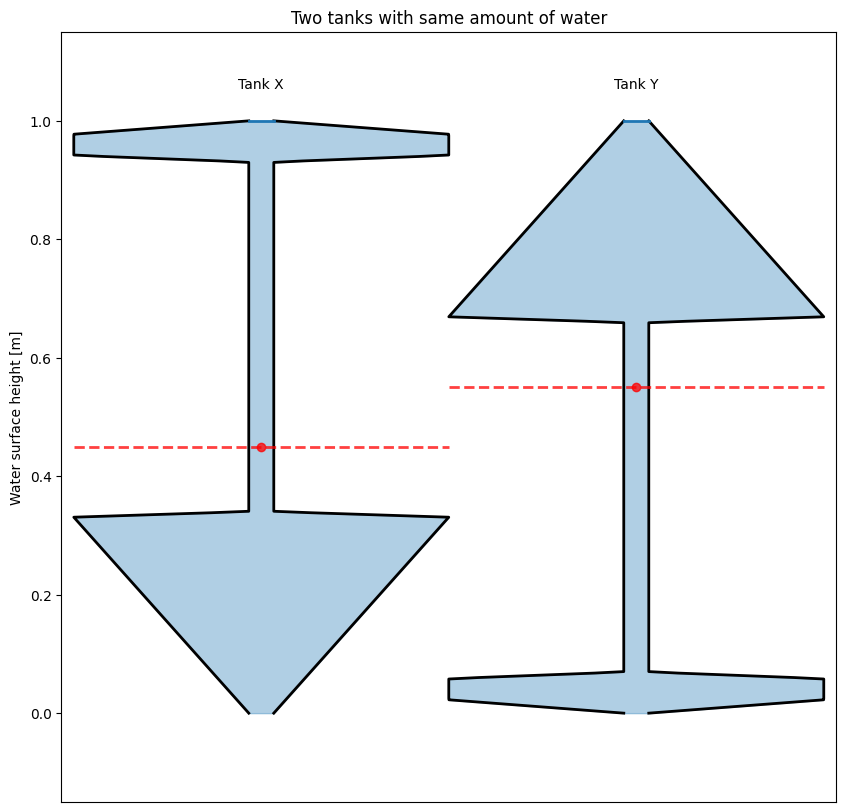

In [10]:
# draw the tank in the figure
def draw_tank(ax, cx, radii, heights, h0, r_hole,label,n=400, water_color="tab:blue"):
    #params:
    # ax : plot figure reference
    # cx : offset in x coordinate of the simmetry axis of the tank
    # rb : bottom radius of the tank
    # rt : top radius of the tank
    # tank_height : height of the tank
    # h0: height of the water surface
    # r_hole: radius of the hole in the bottom surface
    # label: label of the tank
    # n : number of discretized points on the y-axis
    # water_color : desired color of the water

    tank_height = np.sum(heights)
    # array of discretized h (vertical coordinates)
    h = np.linspace(0, tank_height, n)
    # array of radii associated to the values of h
    r = calc_r_h(h, radii, heights)

    # x-coordinates of the left line representing the wall of the tank (shifted by cx)
    xL = cx - r
    # x-coordinates of the right line representing the wall of the tank (shifted by cx)
    xR = cx + r

    # plot tank walls
    ax.plot(xL, h, color="k", lw=2)
    ax.plot(xR, h, color="k", lw=2)

    # bottom: open in the middle (hole)
    # left bottom segment: from (cx-rb) to (cx-r_hole)
    ax.plot([cx - radii[0], cx - r_hole], [0, 0], color="k", lw=2)
    # right bottom segment: from (cx+r_hole) to (cx+rb)
    ax.plot([cx + r_hole, cx + radii[0]], [0, 0], color="k", lw=2)

    # a short vertical tick to show the opening
    #ax.plot([cx - r_hole, cx - r_hole], [0, -0.03*tank_height], color="k", lw=2)
    #ax.plot([cx + r_hole, cx + r_hole], [0, -0.03*tank_height], color="k", lw=2)

    # water fill (0 -> h0)
    h0 = float(np.clip(h0, 0.0, tank_height))
    hw = np.linspace(0, h0, n)
    rw = calc_r_h(hw, radii, heights)
    xLw = cx - rw
    xRw = cx + rw
    ax.fill_betweenx(hw, xLw, xRw, color=water_color, alpha=0.35)

    # water surface line
    r0 = calc_r_h(h0, radii, heights)
    ax.plot([cx - r0, cx + r0], [h0, h0], color=water_color, lw=2)

    #tank centroid
    cm = calc_tank_centroid(radii, heights)
    ax.plot([cx - np.max(radii), cx + np.max(radii)], [cm,cm], color="red", lw=2, alpha=0.75, linestyle='--')
    ax.plot(cx, cm, "o", color="red", ms=6,alpha=0.75)

    # label
    ax.text(cx, tank_height + 0.05*tank_height, label, ha="center", va="bottom")


# plot initialization
fig, ax = plt.subplots(figsize=(10, 10))

# x-coordinate shift for the tank X
cx_tank_x = -1*np.max(obj_radii)
cx_tank_y = +1*np.max(obj_radii)

H_T = np.sum(obj_heights)

draw_tank(ax, cx_tank_x, obj_radii,obj_heights, H_T, r_hole,"Tank X")
draw_tank(ax, cx_tank_y, obj_radii[::-1], obj_heights[::-1], H_T, r_hole,"Tank Y")

ax.set_xlabel("x [m]")
ax.set_ylabel("Water surface height [m]")
ax.set_title(f"Two tanks with same amount of water")

# update x limits based on actual tank centers
x_min = min(cx_tank_x - np.max(obj_radii), cx_tank_y - np.max(obj_radii)) - 0.2
x_max = max(cx_tank_x + np.max(obj_radii), cx_tank_y + np.max(obj_radii)) + 0.2
ax.set_xlim(x_min, x_max)

ax.set_ylim(-0.15*H_T, 1.15*H_T)

# hide x-axis info and grid
ax.get_xaxis().set_visible(False)
ax.grid(False)

#ax.set_aspect("equal", adjustable="box")

plt.show()

In [11]:
# generic first order ODE implementing the explicit Euler method
def first_order_ODE_solver(f,t0,y0,epsilon,max_time,*f_args):
    # parameters:
    # f:  f(t,y) pointer
    # t0: initial time t0
    # y0: initial condition y(t0)
    # epsilon: discretization step
    # max_time: final time tf where the solver stops
    # f_args: additional arguments for the functuon f(t,y)

    # returns:
    # time array
    # y solution array

    t = [t0]
    y = [y0]
    while t[-1]<max_time:
        y.append(y[-1]+epsilon*f(t[-1],y[-1],*f_args))
        t.append(t[-1]+epsilon)
    return np.array(t), np.array(y)

# definition of the function f(t,y) for the tank problem
def tank_f(t,h,r_hole,g,radii,heights):
    # parameters:
    # t: time for evaluating f(t,y)
    # y: y value for evaluating f(t,y)
    # r_hole: hole radius of the tank
    # g: gravitational acceleration
    # rb: bottom radius of the tank
    # rt: top radius of the tank
    # tank_height: height of the tank

    # returns:
    # f(t,y)

    # if height is less than zero, then the tank is empty.
    if h<=0:
        return 0.0
    if h>np.sum(heights):
        h = np.sum(heights)
    r_of_h = calc_r_h(h,radii,heights)
    return -((r_hole/r_of_h)**2)*np.sqrt(2*g*h)

In [12]:
epsilon = 0.001 # time discretization step - 1 ms
observation_time = max(Tf_X,Tf_Y)+1 # [s]

# get t,h (solution) for the tank X
tank_x_t, tank_x_h =  first_order_ODE_solver(
    tank_f,0,H_T,epsilon,observation_time,r_hole,9.81,obj_radii,obj_heights
)

# get t,h (solution) for the tank Y
tank_y_t, tank_y_h =  first_order_ODE_solver(
    tank_f,0,H_T,epsilon,observation_time,r_hole,9.81,obj_radii[::-1],obj_heights[::-1]
)

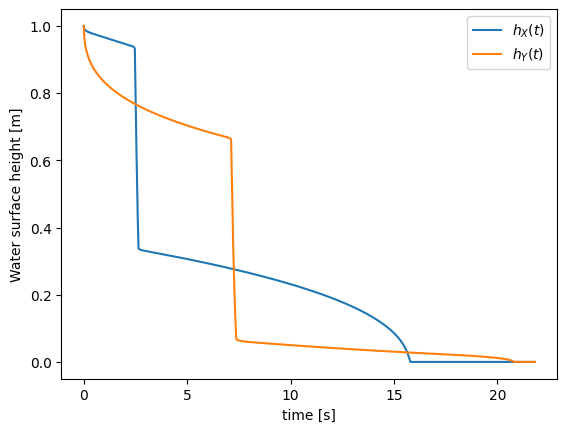

In [13]:
plt.xlabel("time [s]")
plt.ylabel("Water surface height [m]")
plt.plot(tank_x_t,tank_x_h,label=r"$h_X(t)$")
plt.plot(tank_y_t,tank_y_h,label=r"$h_Y(t)$")
plt.legend()
plt.show()

In [14]:
# get time index when the tank X empties
idx_X = np.where(tank_x_h <= 0)[0][0]
# get time index when the tank X empties
idx_Y = np.where(tank_y_h <= 0)[0][0]

print(f'Tank X empties after {idx_X*epsilon} s')
print(f'Tank Y empties after {idx_Y*epsilon} s')

Tank X empties after 15.8 s
Tank Y empties after 20.805 s


In [15]:
#Draw static tank geometry and create dynamic water artists
#Returns a dictionary with everything needed for animation updates
def init_tank_artists(ax, cx, radii, heights, r_hole, label,n=400, water_color="tab:blue"):
    # params
    # ax : plot figure reference
    # cx : offset in x coordinate of the simmetry axis of the tank
    # rb : bottom radius of the tank
    # rt : top radius of the tank
    # tank_height : height of the tank
    # h0: height of the water surface
    # r_hole: radius of the hole in the bottom surface
    # label: label of the tank
    # n : number of discretized points on the y-axis
    # water_color : desired color of the water

    # returns:
    # dictionary of the grafical definitions for the tank

    tank_height = np.sum(heights)
    # array of discretized h (vertical coordinates)
    h = np.linspace(0, tank_height, n)
    # array of radii associated to the values of h
    r = calc_r_h(h, radii, heights)

    # x-coordinates of the left line representing the wall of the tank (shifted by cx)
    xL = cx - r
    # x-coordinates of the right line representing the wall of the tank (shifted by cx)
    xR = cx + r

    # ---- STATIC PARTS ----
    # walls
    ax.plot(xL, h, color="k", lw=2)
    ax.plot(xR, h, color="k", lw=2)

    # bottom with hole gap
    ax.plot([cx - radii[0], cx - r_hole], [0, 0], color="k", lw=2)
    ax.plot([cx + r_hole, cx + radii[0]], [0, 0], color="k", lw=2)

    # hole markers
    #ax.plot([cx - r_hole, cx - r_hole], [0, -0.03*tank_height], color="k", lw=2)
    #ax.plot([cx + r_hole, cx + r_hole], [0, -0.03*tank_height], color="k", lw=2)

    # label
    ax.text(cx, tank_height + 0.05*tank_height, label, ha="center", va="bottom")

    # ---- DYNAMIC WATER OBJECTS (initially empty) ----
    
    # Start with h = 0 (bottom of the tank)

    #water surface height (y coordinate)
    hw = np.array([0.0]) # bottom of the tank
    # corresponding section radius at the water surface height
    rw = calc_r_h(hw, radii, heights) #returns rb

    #left x coordinate of the water at the surface
    xLw = cx - rw
    #right x coordiante of the water at the surface
    xRw = cx + rw

    # fills the area of a polygon. Here are inserted the two points of the bottom of the tank
    # when updating, the polygon fill will be done using the real water height considered in the update phase
    # in this specific case, area = 0, no area to fill
    water_poly = ax.fill(
        np.concatenate([xLw, xRw[::-1]]), #polygon vertices x coordinates
        np.concatenate([hw, hw[::-1]]),   #polygon vertices y coordinates
        color=water_color,
        alpha=0.35
    )[0]

    # water line, initiliazed at the bottom of the tank (it will be updated later)
    water_line, = ax.plot(
        [xLw[0], xRw[0]],
        [0, 0],
        color=water_color,
        lw=2,
        alpha=0.35
    )

    return {
        "cx": cx,
        "radii": radii,
        "heights": heights,
        "n": n,
        "water_poly": water_poly,
        "water_line": water_line,
        "r_hole": r_hole
    }

In [16]:
#Update water polygon and surface line for given height of the water surface
def update_water(artists, h_level):
    #params:
    # artists: artirts reference to update
    # h_level: actual water level for which the update must be done

    #returns:
    # updated artists

    #retrieves the artists data
    cx = artists["cx"]
    radii = artists["radii"]
    heights = artists["heights"]
    n = artists["n"]
    r_hole = artists["r_hole"]

    tank_height = np.sum(heights)
    #assure h_level is between 0 and tank_height
    h_level = float(max(0.0, min(h_level, tank_height)))

    #retrieves the coordinates of the points of the polygon for water filling
    #y coordinates
    hw = np.linspace(0, h_level, n)
    #x coordinates
    rw = calc_r_h(hw, radii,heights)

    #shifting the x coordinates for the considered tank
    xLw = cx - rw
    xRw = cx + rw

    # create the polygon points
    X = np.concatenate([xLw, xRw[::-1]])
    Y = np.concatenate([hw, hw[::-1]])
    #update the water polygon to fill
    artists["water_poly"].set_xy(np.column_stack([X, Y]))

    #update the water surface line
    r0 = calc_r_h(h_level, radii,heights)

    #if h_level is greater than 0 then draw it, otherwise remove the line
    if h_level>0.0:
        artists["water_line"].set_data(
            [cx - r0, cx + r0],
            [h_level, h_level]
        )
    else:
        artists["water_line"].set_visible(False)

    return artists["water_poly"], artists["water_line"]

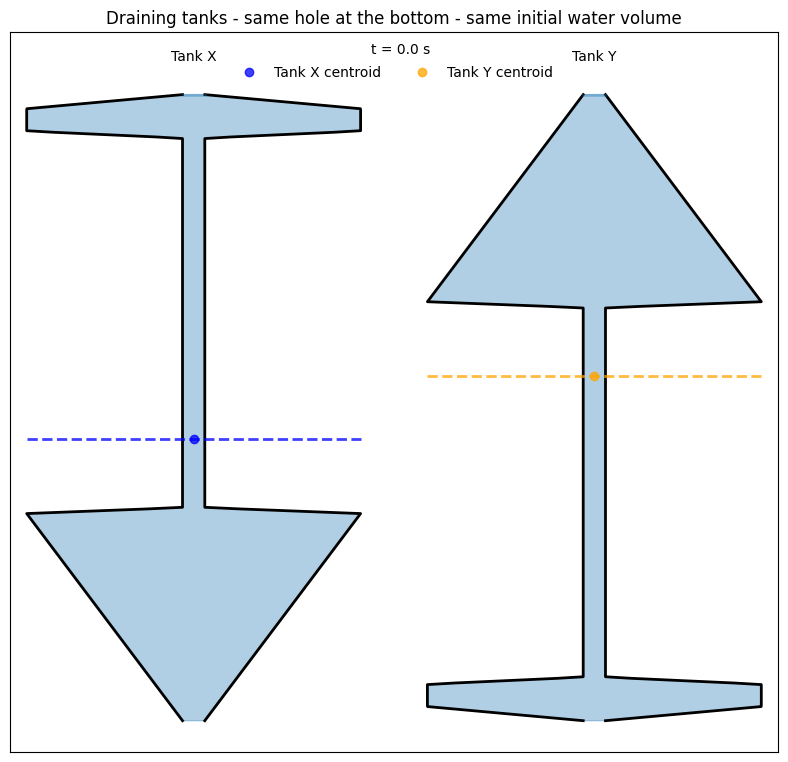

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.92)

cx_X = -1.2*np.max(obj_radii)
cx_Y = +1.2*np.max(obj_radii)

# static + dynamic artists
artists_X = init_tank_artists(ax, cx_X, obj_radii,obj_heights, r_hole, "Tank X")
artists_Y = init_tank_artists(ax, cx_Y, obj_radii[::-1],obj_heights[::-1], r_hole, "Tank Y")

ax.set_title("Draining tanks - same hole at the bottom - same initial water volume")
ax.margins(x=0, y=0)
ax.grid(False)
ax.get_xaxis().set_visible(False)

# good limits
max_r = np.max(obj_radii)
x_min = min(cx_X - max_r, cx_Y - max_r) - 0.3
x_max = max(cx_X + max_r, cx_Y + max_r) + 0.3
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.05*H_T, 1.1*H_T)

# remove y ticks too for a cleaner representation
ax.set_yticks([])

#Tanks centroids
cmX = calc_tank_centroid(obj_radii, obj_heights)
cmX_line , = ax.plot([cx_X - np.max(obj_radii), cx_X + np.max(obj_radii)], [cmX,cmX], color="blue", lw=2, alpha=0.75,linestyle="--")
cmX_point , = ax.plot(cx_X, cmX, "o", color="blue", ms=6,label="Tank X centroid",alpha=0.75)
cmY = calc_tank_centroid(obj_radii[::-1], obj_heights[::-1])
cmY_line , = ax.plot([cx_Y - np.max(obj_radii), cx_Y + np.max(obj_radii)], [cmY,cmY], color="orange", lw=2,alpha=0.75,linestyle="--")
cmY_point , =ax.plot(cx_Y, cmY, "o", color="orange", ms=6,label="Tank Y centroid",alpha=0.75)
ax.legend(loc="upper center",
          bbox_to_anchor=(0.5, 0.97),
          frameon=False,
          ncol=2,
          fontsize=10)

# time text
time_text = ax.text(0.47, 0.97, "", transform=ax.transAxes)

# animate until both are empty
T_end = max(tank_x_t[idx_X], tank_y_t[idx_Y])

# set animation frames per second
fps = 60
tot_frames = int(T_end*fps)+1
t_anim = np.linspace(0, T_end, tot_frames)

# interpolate heights to the common timeline
hX_anim = np.interp(t_anim, tank_x_t, tank_x_h)
hY_anim = np.interp(t_anim, tank_y_t, tank_y_h)

def init():
    # initialize with first frame values
    update_water(artists_X, hX_anim[0])
    update_water(artists_Y, hY_anim[0])
    time_text.set_text(f"t = {t_anim[0]:.1f} s")
    return (*update_water(artists_X, hX_anim[0]), *update_water(artists_Y, hY_anim[0]), time_text)

def update(i):
    update_water(artists_X, hX_anim[i])
    update_water(artists_Y, hY_anim[i])
    time_text.set_text(f"t = {t_anim[i]:.1f} s")
    return (*update_water(artists_X, hX_anim[i]), *update_water(artists_Y, hY_anim[i]), time_text)

anim = FuncAnimation(fig, update, frames=len(t_anim), init_func=init, blit=True, interval=1000/fps)

plt.show()

In [18]:
HTML(anim.to_html5_video()) # works if ffmpeg is installed
# try this otherwise
#HTML(anim.to_jshtml())